# Resumen de performance por algoritmo (iteraciones)

Este notebook recorre todas las iteraciones en `Resultados/classification_exclude_prod`,
lee `resultados_modelos_completos.csv` y construye dos tablas:

- Accuracy (media y desviacion estandar)
- F1 Macro (media y desviacion estandar)

Columnas requeridas por tabla:

- Nitrogen, std Nitrogen, Phosphorus, std Phosphorus, Potassium, std Potassium

In [1]:
from pathlib import Path
import pandas as pd
from utils import plot_confusion_matrix

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

In [2]:
# Ruta base de iteraciones
#base_path = Path('/home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod')
base_path = Path(R'D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod')

csv_files = sorted(base_path.glob('iter_*/resultados_modelos_completos.csv'))
print(f'CSV encontrados: {len(csv_files)}')
for p in csv_files[:5]:
    print('-', p)

if not csv_files:
    raise FileNotFoundError(f'No se encontraron archivos resultados_modelos_completos.csv en: {base_path}')

CSV encontrados: 20
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod\iter_01_seed_42\resultados_modelos_completos.csv
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod\iter_02_seed_43\resultados_modelos_completos.csv
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod\iter_03_seed_44\resultados_modelos_completos.csv
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod\iter_04_seed_45\resultados_modelos_completos.csv
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outlier

In [3]:
# Cargar y concatenar todos los CSV de iteraciones
frames = []
for csv_path in csv_files:
    df_i = pd.read_csv(csv_path)
    df_i['iteration_folder'] = csv_path.parent.name
    frames.append(df_i)

df_all = pd.concat(frames, ignore_index=True)
print('Total filas consolidadas:', len(df_all))
df_all.head()

Total filas consolidadas: 300


,Model,N_Classes,Accuracy_Train,Accuracy_Test,F1_Train,F1_Test,F1_Macro_Test,Best_Params,iteration_folder
0,RF,3_Nitrogen,1.000000,0.749632,1.000000,0.749632,0.749076,"{'clf__max_depth': 20, 'clf__n_estimators': 200}",iter_01_seed_42
1,RF,3_Phosphorus,1.000000,0.767305,1.000000,0.767305,0.767290,"{'clf__max_depth': 30, 'clf__n_estimators': 200}",iter_01_seed_42
2,RF,3_Potassium,1.000000,0.774669,1.000000,0.774669,0.774265,"{'clf__max_depth': 30, 'clf__n_estimators': 300}",iter_01_seed_42
3,SVM,3_Nitrogen,1.000000,0.678940,1.000000,0.678940,0.678824,"{'clf__C': 100, 'clf__gamma': 0.1, 'clf__kerne...",iter_01_seed_42
4,SVM,3_Phosphorus,0.992261,0.693667,0.992261,0.693667,0.693508,"{'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel...",iter_01_seed_42


In [4]:
# Validar columnas requeridas
required_cols = ['Model', 'N_Classes', 'Accuracy_Test', 'F1_Macro_Test']
missing = [c for c in required_cols if c not in df_all.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas en los CSV: {missing}')

elements = ['Nitrogen', 'Phosphorus', 'Potassium']

# Extraer el elemento desde N_Classes (esperado: 3_Nitrogen, 3_Phosphorus, 3_Potassium)
df_all['Element'] = df_all['N_Classes'].astype(str).str.extract(r'3_(Nitrogen|Phosphorus|Potassium)', expand=False)
df_filtered = df_all[df_all['Element'].isin(elements)].copy()

if df_filtered.empty:
    raise ValueError('No se encontraron filas con N_Classes en formato 3_Nitrogen/3_Phosphorus/3_Potassium.')

# Forzar metricas a numerico
df_filtered['Accuracy_Test'] = pd.to_numeric(df_filtered['Accuracy_Test'], errors='coerce')
df_filtered['F1_Macro_Test'] = pd.to_numeric(df_filtered['F1_Macro_Test'], errors='coerce')

df_filtered = df_filtered.dropna(subset=['Accuracy_Test', 'F1_Macro_Test'])
print('Filas utiles para resumen:', len(df_filtered))
df_filtered[['Model', 'N_Classes', 'Element', 'Accuracy_Test', 'F1_Macro_Test']].head()

Filas utiles para resumen: 300


,Model,N_Classes,Element,Accuracy_Test,F1_Macro_Test
0,RF,3_Nitrogen,Nitrogen,0.749632,0.749076
1,RF,3_Phosphorus,Phosphorus,0.767305,0.767290
2,RF,3_Potassium,Potassium,0.774669,0.774265
3,SVM,3_Nitrogen,Nitrogen,0.678940,0.678824
4,SVM,3_Phosphorus,Phosphorus,0.693667,0.693508


In [5]:
# Agregar por algoritmo y elemento (media y std por metrica)
agg = (
    df_filtered
    .groupby(['Model', 'Element'], as_index=False)
    .agg(
        accuracy_mean=('Accuracy_Test', 'mean'),
        accuracy_std=('Accuracy_Test', 'std'),
        f1_macro_mean=('F1_Macro_Test', 'mean'),
        f1_macro_std=('F1_Macro_Test', 'std')
    )
)

agg.head()

,Model,Element,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,KNN,Nitrogen,0.700221,0.011463,0.700016,0.011287
1,KNN,Phosphorus,0.682916,0.019978,0.681244,0.020038
2,KNN,Potassium,0.705155,0.016285,0.704125,0.016632
3,MLP,Nitrogen,0.684315,0.013458,0.684141,0.013485
4,MLP,Phosphorus,0.685493,0.018748,0.685303,0.018679


In [6]:
def build_metric_table(agg_df, mean_col, std_col, elements_order):
    models = sorted(agg_df['Model'].unique())

    mean_wide = agg_df.pivot(index='Model', columns='Element', values=mean_col).reindex(columns=elements_order)
    std_wide = agg_df.pivot(index='Model', columns='Element', values=std_col).reindex(columns=elements_order)

    out = pd.DataFrame(index=models)
    for e in elements_order:
        out[e] = mean_wide[e]
        out[f'std {e}'] = std_wide[e]

    out.index.name = 'Model'
    return out.reset_index()

table_accuracy = build_metric_table(agg, 'accuracy_mean', 'accuracy_std', elements)
table_f1_macro = build_metric_table(agg, 'f1_macro_mean', 'f1_macro_std', elements)

# Redondear para visualizacion
table_accuracy = table_accuracy.round(4)
table_f1_macro = table_f1_macro.round(4)

In [7]:
print('Tabla final - Accuracy (media y std por elemento)')
display(table_accuracy.sort_values('Nitrogen', ascending=False))

print('Tabla final - F1 Macro (media y std por elemento)')
display(table_f1_macro.sort_values('Nitrogen', ascending=False))

# === Mejores iteraciones por elemento y métrica ===
best_rows = []
for elem in elements:
    df_e = df_filtered[df_filtered['Element'] == elem]
    if df_e.empty:
        continue
    # Mejor Accuracy
    idx_acc = df_e['Accuracy_Test'].idxmax()
    row_acc = df_e.loc[idx_acc]
    best_rows.append({
        'Element': elem,
        'Metric': 'Accuracy_Test',
        'Value': float(row_acc['Accuracy_Test']),
        'Model': row_acc['Model'],
        'Iteration': row_acc.get('iteration_folder', None)
    })
    # Mejor F1 Macro
    idx_f1 = df_e['F1_Macro_Test'].idxmax()
    row_f1 = df_e.loc[idx_f1]
    best_rows.append({
        'Element': elem,
        'Metric': 'F1_Macro_Test',
        'Value': float(row_f1['F1_Macro_Test']),
        'Model': row_f1['Model'],
        'Iteration': row_f1.get('iteration_folder', None)
    })


best_iterations_df = pd.DataFrame(best_rows)
print('\nMejores métricas por elemento (valor, modelo, iteración):')
display(best_iterations_df)

Tabla final - Accuracy (media y std por elemento)


,Model,Nitrogen,std Nitrogen,Phosphorus,std Phosphorus,Potassium,std Potassium
4,XGB,0.7770,0.0177,0.7871,0.0148,0.8057,0.0155
2,RF,0.7743,0.0156,0.7589,0.0181,0.7908,0.0161
0,KNN,0.7002,0.0115,0.6829,0.0200,0.7052,0.0163
3,SVM,0.6990,0.0180,0.6948,0.0193,0.7193,0.0191
1,MLP,0.6843,0.0135,0.6855,0.0187,0.7029,0.0181


Tabla final - F1 Macro (media y std por elemento)


,Model,Nitrogen,std Nitrogen,Phosphorus,std Phosphorus,Potassium,std Potassium
4,XGB,0.7770,0.0177,0.7870,0.0148,0.8057,0.0155
2,RF,0.7741,0.0157,0.7589,0.0181,0.7908,0.0161
0,KNN,0.7000,0.0113,0.6812,0.0200,0.7041,0.0166
3,SVM,0.6989,0.0180,0.6946,0.0194,0.7193,0.0191
1,MLP,0.6841,0.0135,0.6853,0.0187,0.7029,0.0182



Mejores métricas por elemento (valor, modelo, iteración):


,Element,Metric,Value,Model,Iteration
0,Nitrogen,Accuracy_Test,0.805596,XGB,iter_04_seed_45
1,Nitrogen,F1_Macro_Test,0.805675,XGB,iter_17_seed_58
2,Phosphorus,Accuracy_Test,0.812960,XGB,iter_07_seed_48
3,Phosphorus,F1_Macro_Test,0.812812,XGB,iter_07_seed_48
4,Potassium,Accuracy_Test,0.840943,XGB,iter_09_seed_50
5,Potassium,F1_Macro_Test,0.840892,XGB,iter_09_seed_50


3_Nitrogen
3_Nitrogen
3_Nitrogen


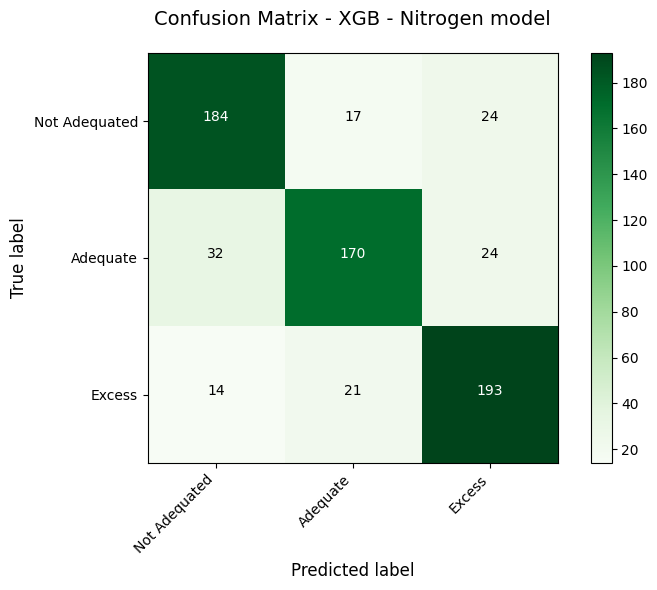

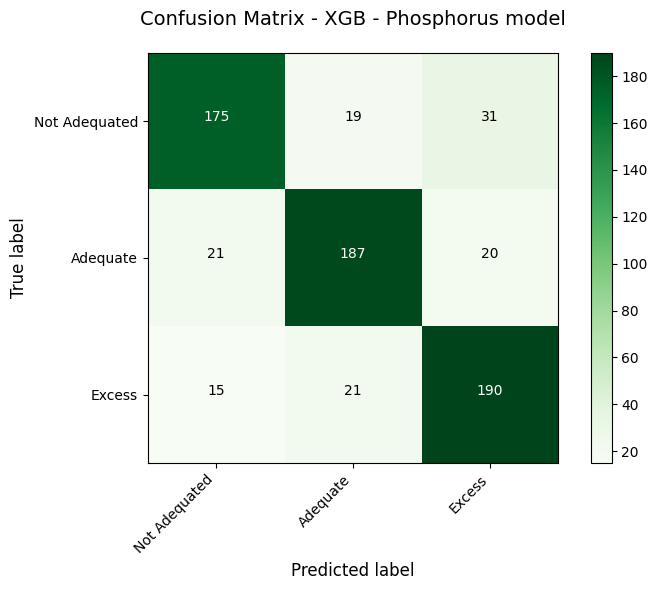

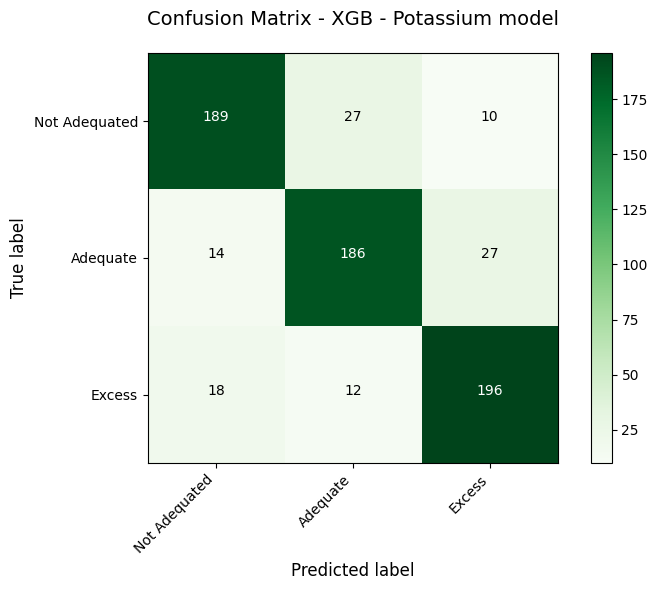

In [8]:
# Matrices de confusión para mejores iteraciones por elemento
for elem in elements:
    # extraer iteration y modelo para mejor Accuracy_Test
    best_acc_row = best_iterations_df[(best_iterations_df['Element'] == elem) & (best_iterations_df['Metric'] == 'Accuracy_Test')]
    if best_acc_row.empty:
        print(f'No se encontró mejor iteración para {elem} - Accuracy_Test')
        continue
    #crear ruta al modelo
    iteration_folder = best_acc_row['Iteration'].values[0]
    model_name = best_acc_row['Model'].values[0]
    model_path = base_path / iteration_folder / "class_results_individual_elements.pkl"
    if not model_path.exists():
        print(f'No se encontró el archivo de resultados individuales para {elem} - Accuracy_Test en: {model_path}')
        continue
    # cargar resultados individuales
    try:
        results_individual = pd.read_pickle(model_path)
    except Exception as e:
        print(f'Error al cargar el archivo de resultados individuales para {elem} - Accuracy_Test: {e}')
        continue
    value = results_individual[model_name]
    #print(value.keys())
    print((results_individual['RF'][0]['n_clases']))

    for resultado in value:
        if elem in resultado['n_clases']:
            fig = plot_confusion_matrix(resultado['confusion_matrix_test'], classes=['Not Adequated','Adequate','Excess'], 
                                title=f"Confusion Matrix - {model_name} - {resultado['n_clases'].split('_')[1] } model")
            # Create output directory if it doesn't exist
            output_dir = Path('confusion_matrices')
            output_dir.mkdir(exist_ok=True)
            fig.savefig(f"{output_dir}/{model_name}_{resultado['n_clases'].split('_')[1]}.pdf", bbox_inches='tight')

In [9]:
# Mejores métricas por modelo y elemento
best_model_rows = []
for model in df_filtered['Model'].unique():
    df_m = df_filtered[df_filtered['Model'] == model]
    for elem in elements:
        df_me = df_m[df_m['Element'] == elem]
        if df_me.empty:
            continue
        # Mejor Accuracy
        idx_acc = df_me['Accuracy_Test'].idxmax()
        row_acc = df_me.loc[idx_acc]
        best_model_rows.append({
            'Model': model,
            'Element': elem,
            'Metric': 'Accuracy_Test',
            'Value': float(row_acc['Accuracy_Test']),
            'Iteration': row_acc.get('iteration_folder', None)
        })
        # Mejor F1 Macro
        idx_f1 = df_me['F1_Macro_Test'].idxmax()
        row_f1 = df_me.loc[idx_f1]
        best_model_rows.append({
            'Model': model,
            'Element': elem,
            'Metric': 'F1_Macro_Test',
            'Value': float(row_f1['F1_Macro_Test']),
            'Iteration': row_f1.get('iteration_folder', None)
        })
best_model_iterations_df = pd.DataFrame(best_model_rows)
print('\nMejores métricas por modelo y elemento (valor, iteración):')
display(best_model_iterations_df)


Mejores métricas por modelo y elemento (valor, iteración):


,Model,Element,Metric,Value,Iteration
0,RF,Nitrogen,Accuracy_Test,0.798233,iter_17_seed_58
1,RF,Nitrogen,F1_Macro_Test,0.798039,iter_17_seed_58
2,RF,Phosphorus,Accuracy_Test,0.792342,iter_07_seed_48
3,RF,Phosphorus,F1_Macro_Test,0.792390,iter_07_seed_48
4,RF,Potassium,Accuracy_Test,0.820324,iter_14_seed_55
5,RF,Potassium,F1_Macro_Test,0.820509,iter_14_seed_55
6,SVM,Nitrogen,Accuracy_Test,0.733432,iter_02_seed_43
7,SVM,Nitrogen,F1_Macro_Test,0.733179,iter_02_seed_43
8,SVM,Phosphorus,Accuracy_Test,0.724595,iter_16_seed_57
9,SVM,Phosphorus,F1_Macro_Test,0.724658,iter_16_seed_57


In [10]:
# Guardar resultados en CSV (opcional)
#output_dir = Path('/home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary')
output_dir = base_path / 'iter_summary'
output_dir.mkdir(parents=True, exist_ok=True)

acc_path = output_dir / 'tabla_resumen_accuracy_iteraciones.csv'
f1_path = output_dir / 'tabla_resumen_f1_macro_iteraciones.csv'

table_accuracy.to_csv(acc_path, index=False)
table_f1_macro.to_csv(f1_path, index=False)

print('Archivos guardados:')
print('-', acc_path)
print('-', f1_path)

Archivos guardados:
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod\iter_summary\tabla_resumen_accuracy_iteraciones.csv
- D:\Estudio\OneDrive - Universidad de Antioquia\Estudio\PAI\Codigo\Code_Quindio\Analisis-PAI\Resultados\outliers_experiment_NPK\outlier_20\classification_exclude_prod\iter_summary\tabla_resumen_f1_macro_iteraciones.csv


In [11]:
# Mejor iteracion en promedio (Accuracy) considerando todos los algoritmos
acc_by_iter = (
    df_filtered
    .groupby('iteration_folder', as_index=False)
    .agg(
        accuracy_mean_all_models=('Accuracy_Test', 'mean'),
        n_rows=('Accuracy_Test', 'size'),
        n_models=('Model', 'nunique')
    )
    .sort_values('accuracy_mean_all_models', ascending=False)
    .reset_index(drop=True)
)

acc_by_iter['accuracy_mean_all_models'] = acc_by_iter['accuracy_mean_all_models'].round(4)
best_iter_avg_accuracy = acc_by_iter.iloc[[0]].copy()

print('Ranking de iteraciones por Accuracy promedio (todos los algoritmos):')
display(acc_by_iter)

print('\nMejor iteracion promedio por Accuracy:')
display(best_iter_avg_accuracy)

Ranking de iteraciones por Accuracy promedio (todos los algoritmos):


,iteration_folder,accuracy_mean_all_models,n_rows,n_models
0,iter_19_seed_60,0.7437,15,5
1,iter_04_seed_45,0.7431,15,5
2,iter_20_seed_61,0.7415,15,5
3,iter_17_seed_58,0.7379,15,5
4,iter_13_seed_54,0.7379,15,5
5,iter_02_seed_43,0.7365,15,5
6,iter_07_seed_48,0.7364,15,5
7,iter_08_seed_49,0.7336,15,5
8,iter_11_seed_52,0.7325,15,5
9,iter_14_seed_55,0.7324,15,5



Mejor iteracion promedio por Accuracy:


,iteration_folder,accuracy_mean_all_models,n_rows,n_models
0,iter_19_seed_60,0.7437,15,5
